In [1]:
import sys
from pathlib import Path

ROOT = Path().resolve().parents[0]  # go up from notebooks/
sys.path.append(str(ROOT))

In [2]:
from config import SEED, N_LIST, METHODS, RESULTS_PATH
from models.cvae import train_cvae_on_arrays, sample_cvae_dataset
from models.bootstrap import sample_bootstrap
from models.gmm import sample_gmm
import numpy as np
import pandas as pd
from metrics import *
import ipywidgets as widgets
from IPython.display import display


# Loading Data
1. Breast cancer
2. Pima Indians Diabetes
3. Somethng else 3

#### 1. Breast Cancer

| Dataset | Category | n | p | Class 0 | Class 1 | Source | Notes |
|---------|----------|---|---|--------|--------|--------|-------|
| Breast Cancer | clinical_tabular | 569 | 30 | 212 | 357 | sklearn | moderate n, moderate p, numeric only |

#### 2. Diabetes

| Dataset | Category | n | p | Class 0 | Class 1 | Source | Notes |
|---------|----------|---|---|--------|--------|--------|-------|
| Diabetes| metabolic_tabular | 768 | 8 | 500 | 268 | openml | high n, low p, numeric only |

In [3]:
from loaders import *
data = load_diabetes()

X = data["X"]
y = data["y"]
feature_names = data["feature_names"]

print(data["dataset"], data["category"])
print(X.shape, y.shape)
print(np.bincount(y))

diabetes metabolic_tabular
(768, 8) (768,)
[500 268]


# Helper Functions
- Stratify Sampler

In [4]:
X_small, y_small, idx_small = stratified_subsample(X, y, n0=23, n1=68, seed=42)
print(X_small.shape)
print(np.bincount(y_small))

(91, 8)
[23 68]


- Train & sample CVAE

In [5]:

best_state = train_cvae_on_arrays(
    X,
    y,
    seed=42,
    z_dim=16,
    hidden=128,
    beta=0.5,
    lr=1e-3,
    epochs=200,
    batch_size=32,
)

X_syn, y_syn = sample_cvae_dataset(
    best_state,
    n0=23,
    n1=68,
    seed=42
)

print(X_syn.shape)
print(np.bincount(y_syn))

Epoch  50 | val loss=4.5882 recon=2.4285 kl=4.3194
Epoch 100 | val loss=4.3760 recon=2.1360 kl=4.4801
Epoch 150 | val loss=4.3497 recon=2.1474 kl=4.4045
Epoch 200 | val loss=4.4352 recon=2.2022 kl=4.4662
(91, 8)
[23 68]


- bootstrap

In [6]:
X_syn_b, y_syn_b = sample_bootstrap(X_small, y_small, n0=23, n1=68, seed=42)

- gmm

In [7]:
X_syn_g, y_syn_g = sample_gmm(X_small, y_small, n0=23, n1=68, seed=42, n_components=2)

## Selection Side
- `forward` means keep top k
- `reverse` means drop top k

In [8]:
def select_feature_subset(X, feature_names, mode="full", ranked_idx=None, k=None, drop_idx=None):
    p = X.shape[1]
    
    if mode == "full":
        keep = np.arange(p)

    elif mode == "drop_one":
        keep = np.array([j for j in range(p) if j != drop_idx])

    elif mode == "forward":
        keep = np.array(ranked_idx[:k])

    elif mode == "reverse":
        keep = np.array(ranked_idx[k:])

    else:
        raise ValueError(f"Unknown mode: {mode}")

    return keep

In [9]:
def rank_features_by_rf_importance(X, y, seed=42, n_estimators=15):
    rf = RandomForestClassifier(n_estimators=n_estimators, random_state=seed)
    rf.fit(X, y)
    return np.argsort(rf.feature_importances_)[::-1]

## Displaying Plots

In [10]:
def show_figures(figures, dataset=None, method=None, plot =None):
    for item in figures:
        if dataset is not None and item["dataset"] != dataset:
            continue
        if method is not None and item["method"] != method:
            continue

        fig_obj = item["fig"]

        if isinstance(fig_obj, dict):
            if plot is None:
                selected = fig_obj.items()
            else:
                if plot not in fig_obj:
                    continue
                selected = [(plot, fig_obj[plot])]

            for name, fig in selected:
                print(f"{item['dataset']} | {item['method']} | {name}")
                display(fig)
        else:
            print(f"{item['dataset']} | {item['method']}")
            display(fig_obj)

# The actual tests with numbers or something

RF trial 1/10
RF trial 10/10
({'rf_auc_mean': np.float64(0.7224444444444444), 'rf_auc_sd': np.float64(0.07949501110210287), 'rf_sep_mean': np.float64(0.7224444444444444), 'rf_sep_sd': np.float64(0.07949501110210287), 'corr_mean_abs_diff': np.float64(0.10708118277700363), 'corr_max_abs_diff': np.float64(0.30163264335942486), 'pval_mean': np.float64(0.24343521427889045), 'pval_median': np.float64(0.017675921010736687), 'prop_significant': np.float64(0.625)}, {'corr': <Figure size 1000x400 with 3 Axes>, 'pca': <Figure size 800x600 with 1 Axes>, 'overlap': <Figure size 640x480 with 1 Axes>})


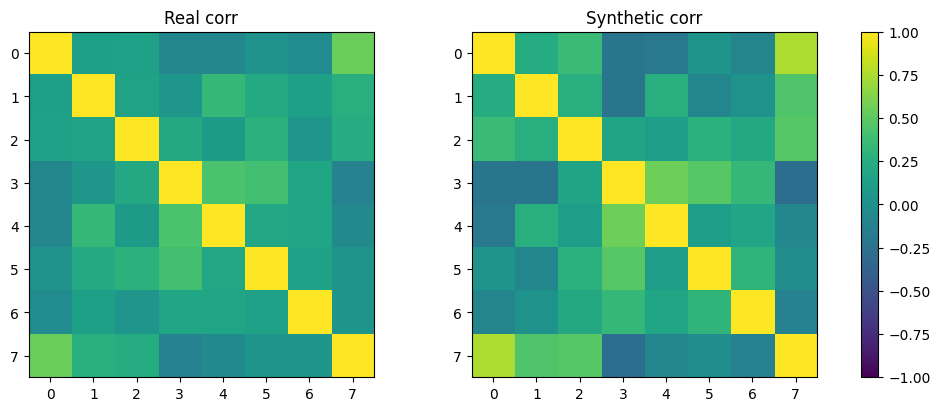

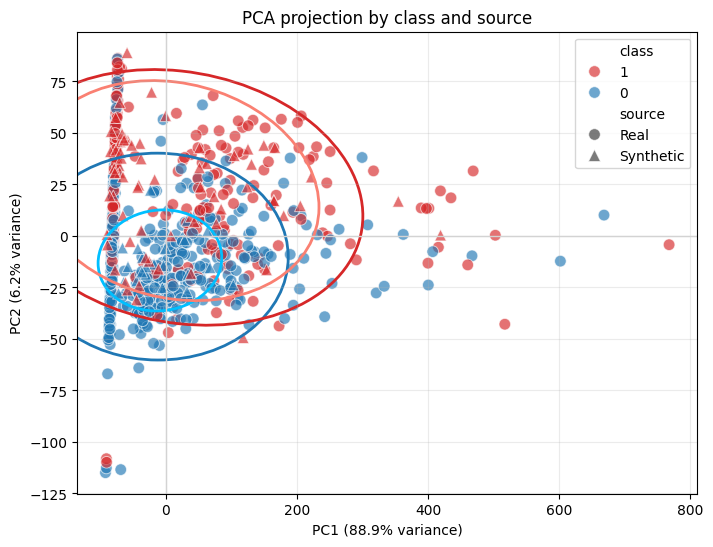

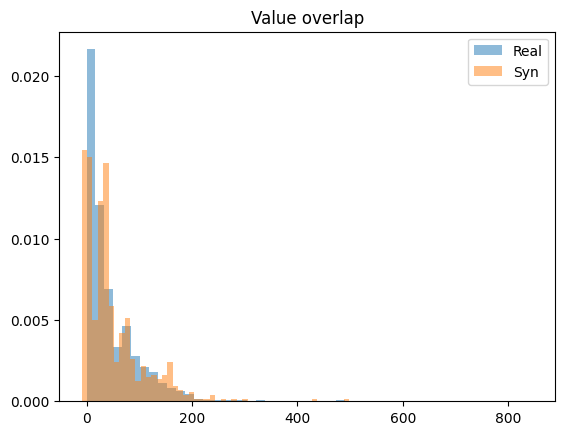

In [11]:
metrics = evaluate_all(X_real=X, X_syn=X_syn, y_real= y, y_syn = y_syn)
print(metrics)

### Results row

In [12]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

def run_experiment(n0, n1, feature_mode = "full", k = None, drop_idx = None, rows=[], figs = None):
    
    
    datasets = [
        load_breast,
        load_diabetes,
    ]

    methods = ["bootstrap", "gmm", "cvae"]
    

    for load_fn in datasets:
        data = load_fn()
        X = data["X"]
        y = data["y"]
        feature_names = data["feature_names"]

        p = X.shape[1]

        if feature_mode == "drop_one" and (drop_idx is None or drop_idx < 0 or drop_idx >= p):
            print(f"Skipping {data['dataset']} drop_idx={drop_idx}; p={p}")
            continue

        if feature_mode == "forward" and (k is None or k <= 0 or k > p):
            print(f"Skipping {data['dataset']} forward k={k}; p={p}")
            continue

        if feature_mode == "reverse" and (k is None or k < 0 or k >= p):
            print(f"Skipping {data['dataset']} reverse k={k}; p={p}")
            continue

        X_small, y_small, _ = stratified_subsample(
            X, y,
            n0=n0,
            n1=n1,
            seed=42
        )
        ranked_idx = rank_features_by_rf_importance(X_small, y_small, seed=42)
        keep = select_feature_subset(
            X_small,
            feature_names,
            mode=feature_mode,
            ranked_idx=ranked_idx,
            k=k,
            drop_idx=drop_idx
        )

        X_use = X_small[:, keep]
        feature_names_use = [feature_names[j] for j in keep]



## SAMPLING
        for method in methods:
            if method == "bootstrap":
                X_syn, y_syn = sample_bootstrap(X_use, y_small, n0, n1, seed=42)

            elif method == "gmm":
                X_syn, y_syn = sample_gmm(X_use, y_small, n0, n1, seed=42)

            elif method == "cvae":
                print("Training CVAE for", data["dataset"])
                best = train_cvae_on_arrays(
                    X_use,
                    y_small,
                    seed=42,
                    epochs=100,   
                    batch_size=32,

                )
                X_syn, y_syn = sample_cvae_dataset(best, n0, n1, seed=42)


        ## EVAL
            print(f"Evaluating {data['dataset']} | {method}")
            metrics, fig = evaluate_all(X_real=X_use, y_real= y_small,  X_syn=X_syn, y_syn = y_syn)

            if feature_mode == "full":
                n_features_used_label = f"{X_use.shape[1]}"
            elif feature_mode == "drop_one":
                n_features_used_label = f"{X_use.shape[1]}"
            elif feature_mode == "forward":
                n_features_used_label = f"top {k}"
            elif feature_mode == "reverse":
                n_features_used_label = f"drop top {k}"
            else:
                n_features_used_label = "unknown"

            row = {
                "dataset": data["dataset"],
                "category": data["category"],
                "n0": n0,
                "n1": n1,
                "method": method,
                "feature_mode": feature_mode,
                "k": None,
                "drop_idx": None,
                "n_features_used": n_features_used_label,
                "n_features_total": X.shape[1],
                "rf_auc_mean": metrics["rf_auc_mean"],
                "rf_auc_sd": metrics["rf_auc_sd"],
                "corr_mean_abs_diff": metrics["corr_mean_abs_diff"],
                "prop_significant": metrics["prop_significant"],
            }

            if feature_mode in {"forward", "reverse"}:
                row["k"] = k
            elif feature_mode == "drop_one":
                row["drop_idx"] = drop_idx

            rows.append(row)

            if figs is not None:
                figs.append({
                    "dataset": data["dataset"],
                    "method": method,
                    "fig": fig,
                })

            if isinstance(fig, dict):
                for f in fig.values():
                    plt.close(f)
            else:
                plt.close(fig)
    # df = pd.DataFrame(rows)
    # display(df)

# Cleaner Run
One call should answer one question:

- “What happens for breast cancer, CVAE, top 10 features?”
- “What happens for HIV, CVAE, full data?”
- “What happens for diabetes, bootstrap, reverse drop top 3?

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def make_subset_metadata(feature_mode, p_total, keep, k=None, drop_idx=None):
    n_used = len(keep)

    if feature_mode == "full":
        return {
            "subset_family": "full",
            "subset_label": "all_features",
            "subset_param": np.nan,
            "n_features_used": n_used,
        }

    if feature_mode == "drop_one":
        return {
            "subset_family": "drop_one",
            "subset_label": f"drop_idx_{drop_idx}",
            "subset_param": drop_idx,
            "n_features_used": n_used,
        }

    if feature_mode == "forward":
        return {
            "subset_family": "forward",
            "subset_label": f"top_{k}",
            "subset_param": k,
            "n_features_used": n_used,
        }

    if feature_mode == "reverse":
        return {
            "subset_family": "reverse",
            "subset_label": f"drop_top_{k}",
            "subset_param": k,
            "n_features_used": n_used,
        }

    raise ValueError(f"Unknown feature_mode: {feature_mode}")


def run_experiment_clean(
    n0,
    n1,
    feature_mode="full",
    k=None,
    drop_idx=None,
    rows=None,
    figs=None,
    cvae_epochs=200,
    seed=42,
):
    if rows is None:
        rows = []

    datasets = [
        # load_breast,
        # load_diabetes,
        load_HIV
    ]

   

    methods = ["bootstrap", "gmm", "cvae"]

    for load_fn in datasets:
       
        data = load_fn()
        X = data["X"]
        y = data["y"]
        feature_names = data["feature_names"]
        p = X.shape[1]

        # guardrails
        if feature_mode == "drop_one" and (drop_idx is None or drop_idx < 0 or drop_idx >= p):
            print(f"Skipping {data['dataset']} drop_idx={drop_idx}; p={p}")
            continue

        if feature_mode == "forward" and (k is None or k <= 0 or k > p):
            print(f"Skipping {data['dataset']} forward k={k}; p={p}")
            continue

        if feature_mode == "reverse" and (k is None or k < 0 or k >= p):
            print(f"Skipping {data['dataset']} reverse k={k}; p={p}")
            continue

        # balanced working sample
        X_small, y_small, _ = stratified_subsample(
            X, y,
            n0=n0,
            n1=n1,
            seed=seed,
        )

        ranked_idx = rank_features_by_rf_importance(X_small, y_small, seed=seed)

        keep = select_feature_subset(
            X_small,
            feature_names,
            mode=feature_mode,
            ranked_idx=ranked_idx,
            k=k,
            drop_idx=drop_idx,
        )

        X_use = X_small[:, keep]
        feature_names_use = [feature_names[j] for j in keep]

        subset_meta = make_subset_metadata(
            feature_mode=feature_mode,
            p_total=p,
            keep=keep,
            k=k,
            drop_idx=drop_idx,
        )

        # generators
        for method in methods:
            if method == "bootstrap":
                X_syn, y_syn = sample_bootstrap(X_use, y_small, n0, n1, seed=seed)

            elif method == "gmm":
                X_syn, y_syn = sample_gmm(X_use, y_small, n0, n1, seed=seed)

            elif method == "cvae":
                print("Training CVAE for", data["dataset"])
                best = train_cvae_on_arrays(
                    X_use,
                    y_small,
                    seed=seed,
                    epochs=cvae_epochs,
                    batch_size=32,
                )
                X_syn, y_syn = sample_cvae_dataset(best, n0, n1, seed=seed)

            print(f"Evaluating {data['dataset']} | {method} | {subset_meta['subset_label']}")
            metrics, fig = evaluate_all(
                X_real=X_use,
                y_real=y_small,
                X_syn=X_syn,
                y_syn=y_syn,
            )

            row = {
                "dataset": data["dataset"],
                "category": data["category"],
                "method": method,
                "n0": n0,
                "n1": n1,
                "seed": seed,

                "feature_mode": feature_mode,
                "subset_family": subset_meta["subset_family"],
                "subset_label": subset_meta["subset_label"],
                "subset_param": subset_meta["subset_param"],
                "n_features_used": subset_meta["n_features_used"],
                "n_features_total": p,

                "rf_sep_mean": metrics.get("rf_sep_mean", np.nan),
                "rf_sep_sd": metrics.get("rf_sep_sd", np.nan),
                "rf_auc_mean": metrics.get("rf_auc_mean", np.nan),
                "rf_auc_sd": metrics.get("rf_auc_sd", np.nan),

                "corr_mean_abs_diff": metrics.get("corr_mean_abs_diff", np.nan),
                "corr_max_abs_diff": metrics.get("corr_max_abs_diff", np.nan),

                # keep if you want, but not primary
                "prop_significant": metrics.get("prop_significant", np.nan),

                # bookkeeping
                "kept_feature_idx": list(map(int, keep)),
                "kept_feature_names": feature_names_use,


                "disc_f1_mean":  metrics.get("disc_f1_mean", np.nan),
                "disc_f1_sd":    metrics.get("disc_f1_sd",   np.nan),
                "tstr_f1":       metrics.get("tstr_f1",       np.nan),
                "trtr_f1":       metrics.get("trtr_f1",       np.nan),
                "utility_gap":   metrics.get("utility_gap",   np.nan),
                "kld_mean":      metrics.get("kld_mean",      np.nan),
                "kld_max":       metrics.get("kld_max",       np.nan),
            }

            rows.append(row)

            if figs is not None:
                figs.append({
                    "dataset": data["dataset"],
                    "method": method,
                    "feature_mode": feature_mode,
                    "subset_label": subset_meta["subset_label"],
                    "fig": fig,
                })

            if isinstance(fig, dict):
                for f in fig.values():
                    plt.close(f)
            else:
                plt.close(fig)

    return rows, figs

In [14]:
rows = []
figures = []
run_experiment(n0=60, n1= 60,  feature_mode = "full", rows = rows, figs = figures)
df = pd.DataFrame(rows)
display(df)
print(len(figures))
print(figures[0].keys())

Evaluating breast_cancer | bootstrap
RF trial 1/10
RF trial 10/10
Evaluating breast_cancer | gmm
RF trial 1/10
RF trial 10/10
Training CVAE for breast_cancer
Epoch  50 | val loss=13.9689 recon=9.9760 kl=7.9860
Epoch 100 | val loss=13.2445 recon=9.4014 kl=7.6861
Evaluating breast_cancer | cvae
RF trial 1/10
RF trial 10/10
Evaluating diabetes | bootstrap
RF trial 1/10
RF trial 10/10
Evaluating diabetes | gmm
RF trial 1/10
RF trial 10/10
Training CVAE for diabetes
Epoch  50 | val loss=5.7260 recon=4.0416 kl=3.3688
Epoch 100 | val loss=5.1663 recon=3.1613 kl=4.0100
Evaluating diabetes | cvae
RF trial 1/10
RF trial 10/10


,dataset,category,n0,n1,method,feature_mode,k,drop_idx,n_features_used,n_features_total,rf_auc_mean,rf_auc_sd,corr_mean_abs_diff,prop_significant
0,breast_cancer,clinical_tabular,60,60,bootstrap,full,None,None,30,30,0.337333,0.080344,0.061283,0.000
1,breast_cancer,clinical_tabular,60,60,gmm,full,None,None,30,30,0.545333,0.137621,0.051594,0.000
2,breast_cancer,clinical_tabular,60,60,cvae,full,None,None,30,30,0.752222,0.081445,0.089356,0.000
3,diabetes,metabolic_tabular,60,60,bootstrap,full,None,None,8,8,0.374222,0.076441,0.070025,0.000
4,diabetes,metabolic_tabular,60,60,gmm,full,None,None,8,8,0.782889,0.087816,0.063537,0.000
5,diabetes,metabolic_tabular,60,60,cvae,full,None,None,8,8,0.899111,0.054107,0.131541,0.125


6
dict_keys(['dataset', 'method', 'fig'])


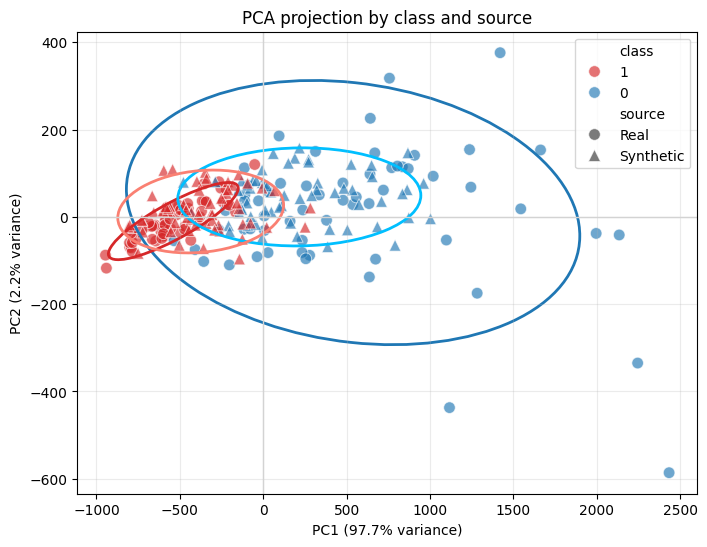

In [15]:
figures[2]['fig']['pca']

breast_cancer | bootstrap | pca


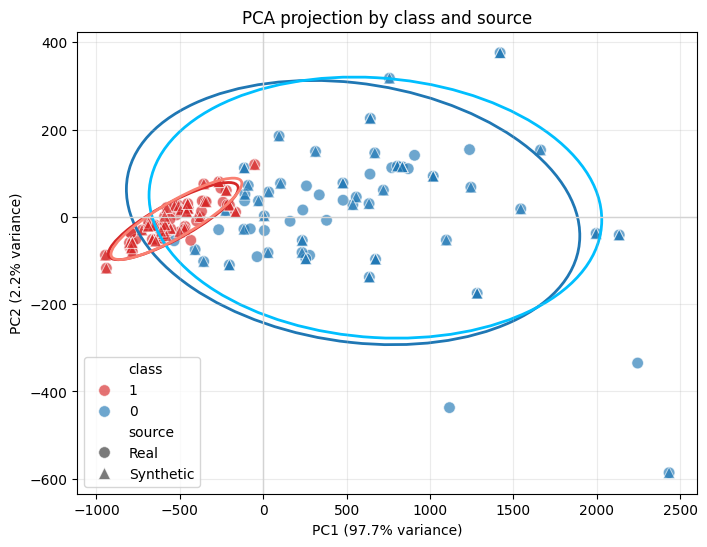

In [16]:
show_figures(figures, dataset="breast_cancer", method="bootstrap", plot="pca")

# Full Data Run
does synthetic quality depend on sample size?

In [17]:
# rows = []

# for n0, n1 in [(23,68),(35,35),(50,50),(60,60)]:
#     run_experiment(
#         n0,
#         n1,
#         feature_mode="full",
#         rows=rows
#     )

# df = pd.DataFrame(rows)
# display(df)

# Drop One Test
Does one feature control the realism?

In [18]:
# rows = []

# for j in range(30):
#     run_experiment(60,60,feature_mode="drop_one",drop_idx=j, rows = rows)

# df = pd.DataFrame(rows)
# display(df)

# Ablation

In [19]:
# all_rows = []

# for k in [3, 5, 10, 15, 20]:
#     run_experiment(
#         n0=60,
#         n1=60,
#         feature_mode="forward",
#         k=k,
#         rows=all_rows
#     )

# for k in [1, 3, 5, 10]:
#     run_experiment(
#         n0=60,
#         n1=60,
#         feature_mode="reverse",
#         k=k,
#         rows=all_rows
#     )

# df_all = pd.DataFrame(all_rows)
# display(df_all)

In [20]:
# summary_figs = evaluate_abl(df_all)

# Cleaner

In [23]:
all_rows = []
all_figs = []

# 1) full-data runs across sample sizes
for n0, n1 in [(23, 68), (35, 35), (50, 50), (60, 60)]:
    print(f"FULL ({n0}, {n1})")
    run_experiment_clean(
        n0=n0,
        n1=n1,
        feature_mode="full",
        rows=all_rows,
        figs=all_figs,
        cvae_epochs=200,
        seed=42,
    )

# 2) drop-one only at fixed size
for j in range(30):
    run_experiment_clean(
        n0=60,
        n1=60,
        feature_mode="drop_one",
        drop_idx=j,
        rows=all_rows,
        figs=all_figs,
        cvae_epochs=200,
        seed=42,
    )

# 3) forward ablation
for k in [3, 5, 10, 15, 20]:
    print(f"FORWARD top {k}")
    run_experiment_clean(
        n0=60,
        n1=60,
        feature_mode="forward",
        k=k,
        rows=all_rows,
        figs=all_figs,
        cvae_epochs=200,
        seed=42,
    )

# 4) reverse ablation
for k in [1, 3, 5, 10]:
    print(f"REVERSE drop top {k}")
    run_experiment_clean(
        n0=60,
        n1=60,
        feature_mode="reverse",
        k=k,
        rows=all_rows,
        figs=all_figs,
        cvae_epochs=200,
        seed=42,
    )

df_all = pd.DataFrame(all_rows)
print(df_all.shape)
display(df_all.head())

FULL (23, 68)
Evaluating breast_cancer | bootstrap | all_features
RF trial 1/10
RF trial 10/10
Evaluating breast_cancer | gmm | all_features
RF trial 1/10
RF trial 10/10
Training CVAE for breast_cancer
Epoch  50 | val loss=8.3628 recon=6.6336 kl=3.4584
Epoch 100 | val loss=9.0991 recon=7.0458 kl=4.1067
Epoch 150 | val loss=7.0014 recon=4.7876 kl=4.4276
Epoch 200 | val loss=7.3040 recon=4.9209 kl=4.7662
Evaluating breast_cancer | cvae | all_features
RF trial 1/10
RF trial 10/10
Evaluating diabetes | bootstrap | all_features
RF trial 1/10
RF trial 10/10
Evaluating diabetes | gmm | all_features
RF trial 1/10
RF trial 10/10
Training CVAE for diabetes
Epoch  50 | val loss=6.3333 recon=4.9940 kl=2.6786
Epoch 100 | val loss=5.2089 recon=3.5982 kl=3.2212
Epoch 150 | val loss=5.6344 recon=3.9749 kl=3.3190
Epoch 200 | val loss=5.2707 recon=3.5190 kl=3.5033
Evaluating diabetes | cvae | all_features
RF trial 1/10
RF trial 10/10
FULL (35, 35)
Evaluating breast_cancer | bootstrap | all_features
RF t

,dataset,category,method,n0,n1,seed,feature_mode,subset_family,subset_label,subset_param,...,n_features_total,rf_sep_mean,rf_sep_sd,rf_auc_mean,rf_auc_sd,corr_mean_abs_diff,corr_max_abs_diff,prop_significant,kept_feature_idx,kept_feature_names
0,breast_cancer,clinical_tabular,bootstrap,23,68,42,full,full,all_features,NaN,...,30,0.657333,0.068830,0.342667,0.068830,0.042124,0.328746,0.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[mean radius, mean texture, mean perimeter, me..."
1,breast_cancer,clinical_tabular,gmm,23,68,42,full,full,all_features,NaN,...,30,0.644889,0.048563,0.644889,0.048563,0.050148,0.210210,0.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[mean radius, mean texture, mean perimeter, me..."
2,breast_cancer,clinical_tabular,cvae,23,68,42,full,full,all_features,NaN,...,30,0.633556,0.077914,0.633556,0.077914,0.065565,0.332908,0.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[mean radius, mean texture, mean perimeter, me..."
3,diabetes,metabolic_tabular,bootstrap,23,68,42,full,full,all_features,NaN,...,8,0.642222,0.110978,0.357778,0.110978,0.054023,0.272801,0.0,"[0, 1, 2, 3, 4, 5, 6, 7]","[preg, plas, pres, skin, insu, mass, pedi, age]"
4,diabetes,metabolic_tabular,gmm,23,68,42,full,full,all_features,NaN,...,8,0.705778,0.108781,0.700444,0.118321,0.057069,0.157955,0.0,"[0, 1, 2, 3, 4, 5, 6, 7]","[preg, plas, pres, skin, insu, mass, pedi, age]"
